# 06 — Environmental Stress Modeling & Multi-Criteria Risk Analysis
**Project:** AI-Based Urban Change & Environmental Risk Intelligence for Chittoor District, AP  
**Stage:** Spatial Risk Modeling & Multi-Criteria Evaluation  

### Objectives:
1. Formulate the Environmental Stress Indicator across the 1 km spatial grid ($N = 6,902$).
2. Evaluate component integration: Urbanization ($C_{urb}$), Vegetation Loss ($C_{veg}$), Moisture Loss ($C_{wat}$).
3. Conduct sensitivity analysis comparing transparent Equal Weights ($1/3$ each) against data-driven PCA weighting.
4. Stratify cells into relative stress quartiles ($Q_1$ to $Q_4$) and extract the authoritative Top 100 Hotspots.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

df_grid = pd.read_csv(project_root / "outputs" / "tables" / "environmental_stress_grid_1km_enriched.csv")
df_top100 = pd.read_csv(project_root / "outputs" / "tables" / "top_100_environmental_stress_cells_enriched.csv")
print(f"Loaded {len(df_grid)} grid cells and {len(df_top100)} top hotspots.")

Loaded 6902 grid cells and 100 top hotspots.


## 1. Indicator Formulation & Component Distributions
$$S_i = w_{urb} C_{urb, i} + w_{veg} C_{veg, i} + w_{wat} C_{wat, i}$$
where $w_{urb} = w_{veg} = w_{wat} = \frac{1}{3}$ and $C \in [0, 1]$.

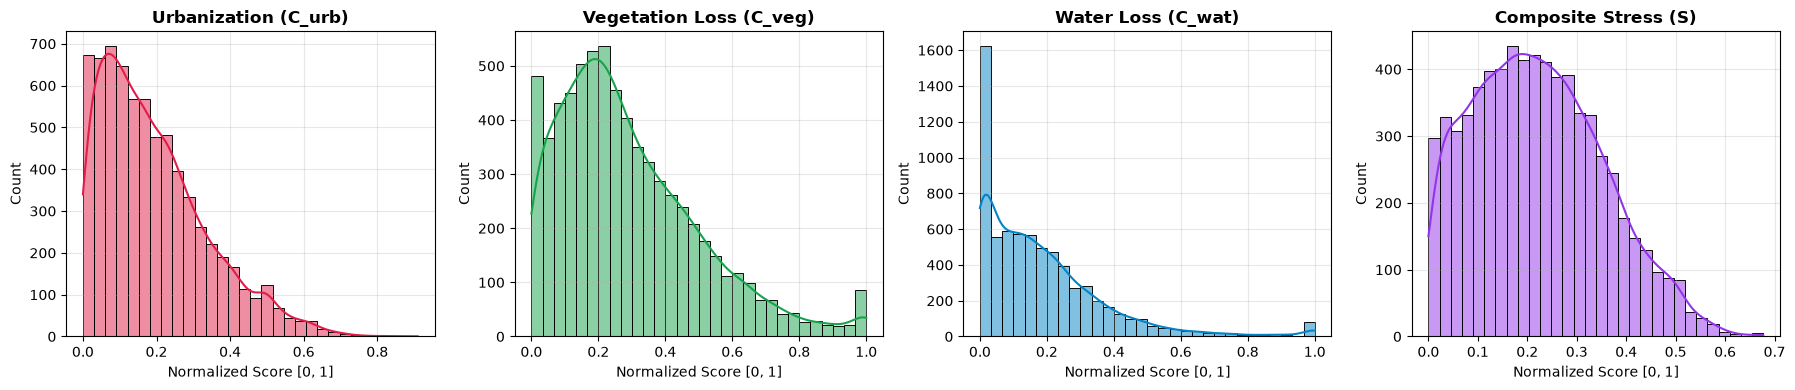

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
components = ["urbanization_component", "vegetation_component", "water_component", "stress_score"]
titles = ["Urbanization (C_urb)", "Vegetation Loss (C_veg)", "Water Loss (C_wat)", "Composite Stress (S)"]
colors = ["#e11d48", "#16a34a", "#0284c7", "#9333ea"]

for ax, comp, title, c in zip(axes, components, titles, colors):
    sns.histplot(df_grid[comp], kde=True, ax=ax, color=c, bins=30)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Normalized Score [0, 1]")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Sensitivity Analysis: Equal vs PCA Weights
Check sensitivity results across weighting schemes and spatial resolutions.

In [3]:
sens_path = project_root / "outputs" / "tables" / "environmental_stress_sensitivity.csv"
df_sens = pd.read_csv(sens_path)
df_sens[["sensitivity_test", "parameter", "n_cells", "mean_score", "median_score", "p90_score", "correlation_with_primary"]]

,sensitivity_test,parameter,n_cells,mean_score,median_score,p90_score,correlation_with_primary
0,Primary Analysis Scale,1 km Grid (step=100 px),6902,0.2213,0.2117,0.3989,1.0
1,Finer Spatial Resolution,500 m Grid (step=50 px),27669,0.1873,0.1711,0.3693,Evaluated across scales
2,Threshold Variation (Relaxed),Spectral threshold ±0.05,6902,0.2971,0.3007,0.4261,0.922
3,Threshold Variation (Strict),Spectral threshold ±0.15,6902,0.1801,0.1570,0.3804,0.954
4,Weighting Scheme (PCA Data-Driven),"w_urb=0.4585, w_veg=0.4514, w_wat=0.09",6902,0.2353,0.2121,0.4490,0.9279


## 3. Top 100 Hotspots Inspection
Inspect the top priority hotspots ranked deterministically by stress score.

In [4]:
print(f"Top 10 Hotspots across Chittoor District:")
df_top100[["rank", "cell_id", "stress_score", "mandal", "evidence_strength", "dominant_evidence", "decision_support_label"]].head(10)

Top 10 Hotspots across Chittoor District:


,rank,cell_id,stress_score,mandal,evidence_strength,dominant_evidence,decision_support_label
0,1,C_052_166,0.6771,Vijayapuram,High (Multi-Source Convergence),Vegetation Spectral Decline (NDVI decrease),Priority Multi-Source Monitoring Zone
1,2,C_035_064,0.6761,Somala,High (Multi-Source Convergence),Vegetation Spectral Decline (NDVI decrease),Priority Multi-Source Monitoring Zone
2,3,C_052_169,0.6670,Vijayapuram,High (Multi-Source Convergence),Vegetation Spectral Decline (NDVI decrease),Priority Multi-Source Monitoring Zone
3,4,C_047_044,0.6610,Punganur,High (Multi-Source Convergence),Vegetation Spectral Decline (NDVI decrease),Priority Multi-Source Monitoring Zone
4,5,C_038_055,0.6559,Chowdepalle,High (Multi-Source Convergence),Urbanization Expansion (NDBI + Dynamic World),Priority Multi-Source Monitoring Zone
5,6,C_045_166,0.6415,Nindra,High (Multi-Source Convergence),Water/Moisture Spectral Decline (NDWI decrease),Priority Multi-Source Monitoring Zone
6,7,C_042_054,0.6192,Chowdepalle,High (Multi-Source Convergence),Water/Moisture Spectral Decline (NDWI decrease),Priority Multi-Source Monitoring Zone
7,8,C_040_056,0.6184,Chowdepalle,High (Multi-Source Convergence),Water/Moisture Spectral Decline (NDWI decrease),Priority Multi-Source Monitoring Zone
8,9,C_055_047,0.6163,Peddapanjani,High (Multi-Source Convergence),Vegetation Spectral Decline (NDVI decrease),Priority Multi-Source Monitoring Zone
9,10,C_073_102,0.6112,Gudipala,High (Multi-Source Convergence),Vegetation Spectral Decline (NDVI decrease),Priority Multi-Source Monitoring Zone


### Scientific Framing Governance:
- **Screening Indicator:** Relative environmental stress is a screening metric to guide field verification, NOT a regulatory hazard map.
- **Equal Weighting Justification:** Sensitivity analysis demonstrates high concordance between Equal and PCA weighting (Pearson $r = 0.9279$; Spearman $\rho = 0.9385$), confirming that the broad spatial ranking is stable without introducing black-box weighting.